# Week 04. Machine Learning with Text Data

Natural Language Processing for Law and Social Science<br>
Elliott Ash, ETH Zurich

In [1]:
# set random seed
import numpy as np
np.random.seed(4)

In [ ]:
# If you are using Google Colab, here's the code to load sc_cases_cleaned.pkl from local. 
from google.colab import files
uploaded = files.upload()

Saving sc_cases_cleaned.pkl to sc_cases_cleaned.pkl


In [2]:
# set up
import warnings; warnings.simplefilter('ignore')
%matplotlib notebook
import pandas as pd
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df=df.reset_index(drop=True)
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,sentiments,year,log_cite_count
0,"JOHN F. HINCK, ET UX. v. UNITED STATES",majority,2007-05-21,ROBERTS,1.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...",[],12.0,159.0,Chief Justice Roberts delivered the opinion of...,-0.999100,2007,5.068904
1,ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.,majority,2002-06-10,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,1234.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.997482,2002,7.118016
2,"REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...",majority,2002-01-22,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,2278.0,JUSTICE GINSBURG delivered the opinion of the ...,-0.997020,2002,7.731053
3,"CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...",majority,2003-04-22,STEVENS,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH']",2.0,1082.0,JUSTICE STEVENS delivered the opinion of the C...,-0.996996,2003,6.986566
4,NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...,majority,2000-04-17,O'CONNOR,1.0,"['BREYER, STEPHEN', 'KENNEDY, ANTHONY', ""O'CON...","['GINSBURG, RUTH', 'STEVENS, JOHN']",10.0,1449.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.996513,2000,7.278629


In [3]:
df = df.assign(authorship_id=(df['authorship']).astype('category').cat.codes)
df['authorship'].value_counts() 

authorship
SCALIA       94
GINSBURG     89
THOMAS       87
KENNEDY      86
BREYER       85
STEVENS      79
SOUTER       77
O'CONNOR     52
REHNQUIST    49
ROBERTS      38
ALITO        32
Name: count, dtype: int64

array([[<Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'log_cite_count'}>]], dtype=object)

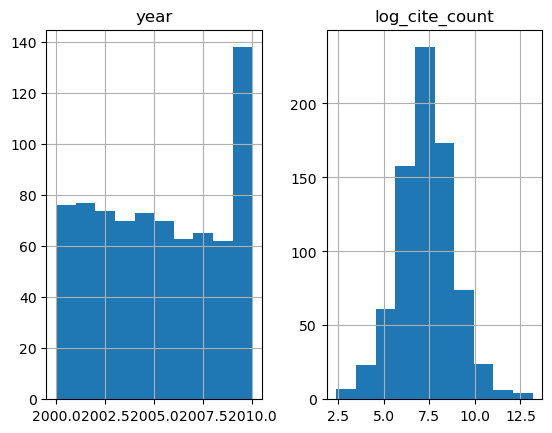

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline
df[['year','log_cite_count']].hist()

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=4,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
words = vectorizer.get_feature_names_out()
print(words)
X

['act' 'congress' 'district' 'state']


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 2534 stored elements and shape (768, 4)>

In [7]:
X = X.todense()
X = X / X.sum(axis=1)  # counts to frequencies
for i, word in enumerate(words):
    column = np.asarray(X[:, i]).flatten()
    df['x_' + word] = column
df


,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,sentiments,year,log_cite_count,authorship_id,x_act,x_congress,x_district,x_state
0,"JOHN F. HINCK, ET UX. v. UNITED STATES",majority,2007-05-21,ROBERTS,1.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...",[],12.0,159.0,Chief Justice Roberts delivered the opinion of...,-0.999100,2007,5.068904,6,0.181818,0.606061,0.212121,0.000000
1,ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.,majority,2002-06-10,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,1234.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.997482,2002,7.118016,4,0.066667,0.000000,0.900000,0.033333
2,"REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...",majority,2002-01-22,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,2278.0,JUSTICE GINSBURG delivered the opinion of the ...,-0.997020,2002,7.731053,2,0.000000,0.000000,0.113924,0.886076
3,"CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...",majority,2003-04-22,STEVENS,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH']",2.0,1082.0,JUSTICE STEVENS delivered the opinion of the C...,-0.996996,2003,6.986566,9,0.541667,0.208333,0.125000,0.125000
4,NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...,majority,2000-04-17,O'CONNOR,1.0,"['BREYER, STEPHEN', 'KENNEDY, ANTHONY', ""O'CON...","['GINSBURG, RUTH', 'STEVENS, JOHN']",10.0,1449.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.996513,2000,7.278629,4,0.062500,0.041667,0.083333,0.812500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,"PAT OSBORN v. BARRY HALEY, et al.",majority,2007-01-22,GINSBURG,0.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...","['SCALIA, ANTONIN', 'THOMAS, CLARENCE']",9.0,2073.0,Justice Ginsburg delivered the opinion of the ...,0.997816,2007,7.636752,2,0.336898,0.080214,0.390374,0.192513
764,"RICHARD WILL, et al. v. SUSAN HALLOCK, et al.",majority,2006-01-18,SOUTER,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],9.0,629.0,Justice Souter delivered the opinion of the Co...,0.998352,2006,6.444131,8,0.434783,0.043478,0.260870,0.260870
765,"ALBERTO R. GONZALES, ATTORNEY GENERAL, et al. ...",majority,2006-01-17,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['ROBERTS, JOHN', 'SCALIA, ANTONIN', 'THOMAS, ...",5.0,1456.0,Justice Kennedy delivered the opinion of the C...,0.998826,2006,7.283448,3,0.232558,0.383721,0.023256,0.360465
766,"DONALD C. WINTER, SECRETARY OF THE NAV., et al...",majority,2008-11-12,ROBERTS,1.0,"['ALITO, SAMUEL', 'KENNEDY, ANTHONY', 'ROBERTS...","['BREYER, STEPHEN', 'GINSBURG, RUTH', 'SOUTER,...",8.0,53160.0,CHIEF JUSTICE Roberts delivered the opinion of...,0.998828,2008,10.881062,6,0.111111,0.044444,0.800000,0.044444


In [8]:
# inspecting data
import numpy as np
features = ['x_'+x for x in words]
cites_features = ['log_cite_count'] + features
df2 = df[cites_features]
corr_matrix = df2.corr()
corr_matrix['log_cite_count'].sort_values(ascending=False)

log_cite_count    1.000000
x_state           0.153254
x_district        0.111862
x_congress       -0.137626
x_act            -0.237354
Name: log_cite_count, dtype: float64

array([[<Axes: xlabel='log_cite_count', ylabel='log_cite_count'>,
        <Axes: xlabel='x_act', ylabel='log_cite_count'>,
        <Axes: xlabel='x_congress', ylabel='log_cite_count'>,
        <Axes: xlabel='x_district', ylabel='log_cite_count'>,
        <Axes: xlabel='x_state', ylabel='log_cite_count'>],
       [<Axes: xlabel='log_cite_count', ylabel='x_act'>,
        <Axes: xlabel='x_act', ylabel='x_act'>,
        <Axes: xlabel='x_congress', ylabel='x_act'>,
        <Axes: xlabel='x_district', ylabel='x_act'>,
        <Axes: xlabel='x_state', ylabel='x_act'>],
       [<Axes: xlabel='log_cite_count', ylabel='x_congress'>,
        <Axes: xlabel='x_act', ylabel='x_congress'>,
        <Axes: xlabel='x_congress', ylabel='x_congress'>,
        <Axes: xlabel='x_district', ylabel='x_congress'>,
        <Axes: xlabel='x_state', ylabel='x_congress'>],
       [<Axes: xlabel='log_cite_count', ylabel='x_district'>,
        <Axes: xlabel='x_act', ylabel='x_district'>,
        <Axes: xlabel='x_cong

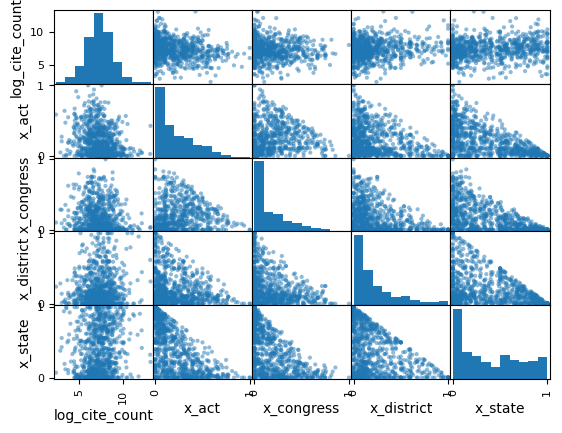

In [9]:
from pandas.plotting import scatter_matrix
scatter_matrix(df2)

<Axes: xlabel='x_act', ylabel='log_cite_count'>

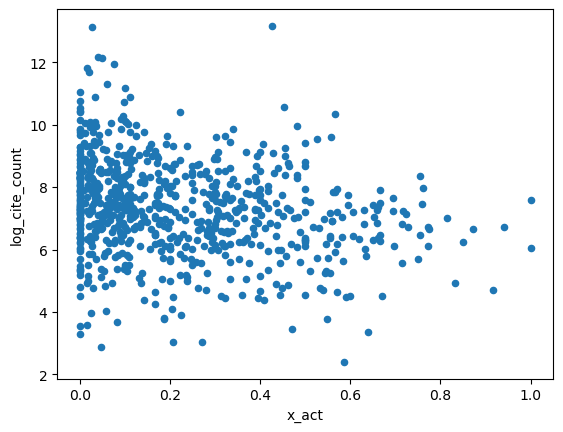

In [10]:
df2.plot(kind='scatter', x='x_act', y='log_cite_count')

# Regression

In [11]:
# create a test set 
from sklearn.model_selection import train_test_split
train, test = train_test_split(df2, test_size=0.2)

In [12]:
Xtrain = train[features]
Ytrain = train['log_cite_count']
Xtrain.head()

,x_act,x_congress,x_district,x_state
596,0.360000,0.240000,0.000000,0.400000
90,0.053763,0.000000,0.946237,0.000000
734,0.000000,0.000000,0.058824,0.941176
694,0.372340,0.361702,0.021277,0.244681
517,0.000000,0.025000,0.150000,0.825000


In [13]:
Ytrain.head()

596     4.553877
90      7.186901
734     7.181592
694     8.183677
517    10.750750
Name: log_cite_count, dtype: float64

In [14]:
# our first machine learning model
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

lin_reg.fit(Xtrain, Ytrain)
lin_reg.coef_ 

array([-0.96897209, -0.30317415,  0.7213188 ,  0.55082744])

In [15]:
# in-sample performance
from sklearn.metrics import mean_squared_error
Ytrain_pred = lin_reg.predict(Xtrain)        
train_mse = mean_squared_error(Ytrain,Ytrain_pred)
train_mse

2.2112149926921125

In [16]:
# out-of-sample performance
Xtest = test[features]
Ytest = test['log_cite_count']
Ytest_pred = lin_reg.predict(Xtest)        
test_mse = mean_squared_error(Ytest,Ytest_pred)
test_mse

1.8870256492767414

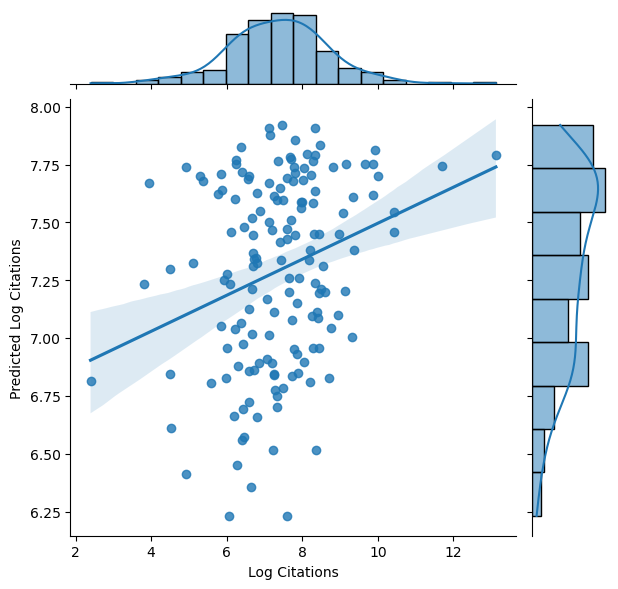

In [17]:
import seaborn as sns

p = sns.jointplot(x=Ytest, y=Ytest_pred, kind='reg')
p.set_axis_labels('Log Citations', 'Predicted Log Citations', fontsize=10)


# Pipelines and Cross-Validation

In [18]:
# missing values
df['authorship_id'].fillna(0,inplace=True)

0      6
1      4
2      2
3      9
4      4
      ..
763    2
764    8
765    3
766    6
767    6
Name: authorship_id, Length: 768, dtype: int8

In [20]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df2)
df2 = pd.DataFrame(X,columns=df2.columns)

In [21]:
X

array([[-1.4934597 , -0.15718649,  2.17515681, -0.04284002, -1.20157476],
       [-0.14206064, -0.71442888, -0.86797524,  2.8444953 , -1.09901001],
       [ 0.26224012, -1.03704289, -0.86797524, -0.45501748,  1.52482999],
       ...,
       [-0.03295744,  0.08835483,  1.05875197, -0.83559267, -0.09244432],
       [ 2.33968555, -0.49935287, -0.64481223,  2.42475052, -1.06482176],
       [ 0.9467979 , -0.49935287, -0.81218449, -0.83993112,  1.43092049]],
      shape=(768, 5))

In [22]:
# Encoding categorical variables
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()
judge = df['authorship_id']
print(judge.values.shape)
print(judge.values.reshape(-1,1).shape)
judge_fes = encoder.fit_transform(judge.values.reshape(-1,1))
judge_ids = ['j_'+str(x) for x in range(len(judge.unique()))]
judge_fes = pd.DataFrame(judge_fes.todense(),columns=judge_ids)
df = pd.concat([df,judge_fes],axis=1)
train, test = train_test_split(df, test_size=0.2)

(768,)
(768, 1)


In [23]:
# Cross-validation
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()

from sklearn.model_selection import cross_val_score
scores = cross_val_score(forest_reg,
                         df[features],
                         df['x_republican'],
                         cv=3,
                         n_jobs=-1)

# the default score for random forest reg is negative MSE.
print(np.abs(scores.mean()),scores.std())

0.15235854081544295 0.04777528469947929


In [24]:
# Grid Search
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [3, 10, 30],
              'max_features': [2, 4],
              'bootstrap': [True, False]}

grid_search = GridSearchCV(forest_reg, 
                           param_grid, 
                           cv=3)              
grid_search.fit(df[features],df['x_republican'])

print(grid_search.best_params_)
print(np.abs(grid_search.best_score_))

{'bootstrap': True, 'max_features': 2, 'n_estimators': 30}
0.15761401347420123


In [25]:
from sklearn.model_selection import RandomizedSearchCV
rand_search = RandomizedSearchCV(forest_reg, param_grid, cv=3)              
rand_search.fit(df[features],df['x_republican'])

print(rand_search.best_params_)
print(np.abs(rand_search.best_score_))

{'n_estimators': 30, 'max_features': 2, 'bootstrap': True}
0.17803127961630905


In [26]:
# Saving and loading
import joblib
joblib.dump(forest_reg,'forest_reg.pkl') # will overwrite local files
forest_reg = joblib.load('forest_reg.pkl')

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer

pipeline = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('forest_reg', RandomForestRegressor()),
])

parameters = {
    'vect__max_df': (0.5, 0.75, 1.0),
    'vect__max_features': (2, 4, 8, 16),
    'forest_reg__n_estimators': [3, 10, 30],
    'forest_reg__max_features': [2, 4],
    'forest_reg__bootstrap': [True, False]}

In [28]:
from pprint import pprint
from time import time

if __name__ == "__main__":
    # multiprocessing requires the fork to happen in a __main__ protected
    # block

    # find the best parameters for both the feature extraction and the
    # classifier
    grid_search = GridSearchCV(pipeline, parameters, n_jobs=-1, verbose=1)

    print("Performing grid search...")
    print("pipeline:", [name for name, _ in pipeline.steps])
    print("parameters:")
    pprint(parameters)
    t0 = time()
    grid_search.fit(df.opinion_text, df.log_cite_count)
    print("done in %0.3fs" % (time() - t0))
    print()

    print("Best score: %0.3f" % grid_search.best_score_)
    print("Best parameters set:")
    best_parameters = grid_search.best_estimator_.get_params()
    for param_name in sorted(parameters.keys()):
        print("\t%s: %r" % (param_name, best_parameters[param_name]))

Performing grid search...
pipeline: ['vect', 'tfidf', 'forest_reg']
parameters:
{'forest_reg__bootstrap': [True, False],
 'forest_reg__max_features': [2, 4],
 'forest_reg__n_estimators': [3, 10, 30],
 'vect__max_df': (0.5, 0.75, 1.0),
 'vect__max_features': (2, 4, 8, 16)}
Fitting 5 folds for each of 144 candidates, totalling 720 fits
done in 165.077s

Best score: 0.170
Best parameters set:
	forest_reg__bootstrap: True
	forest_reg__max_features: 2
	forest_reg__n_estimators: 30
	vect__max_df: 0.75
	vect__max_features: 16


## Nested Cross-Validation

In [29]:
import numpy as np
from sklearn.model_selection import KFold
n = 30

forest_reg = RandomForestRegressor()
non_nested_scores = np.zeros(n)
nested_scores = np.zeros(n)


param_grid = {'n_estimators': [3, 10, 30],
              'max_features': [2, 4],
              'bootstrap': [True, False]}

for i in range(n):

    # Choose cross-validation techniques for the inner and outer loops,

    inner_cv = KFold(n_splits=4, shuffle=True, random_state=i)
    outer_cv = KFold(n_splits=4, shuffle=True, random_state=i)

    # Non_nested parameter search and scoring
    grid_search = GridSearchCV(estimator=forest_reg, param_grid=param_grid, cv=inner_cv)
    grid_search.fit(Xtrain, Ytrain)
    non_nested_scores[i] = grid_search.best_score_

    # Nested CV with parameter optimization
    nested_score = cross_val_score(grid_search, X=Xtrain, y=Ytrain, cv=outer_cv)
    nested_scores[i] = nested_score.mean()

score_difference = non_nested_scores - nested_scores
print("Average difference of {:6f} with std. dev. of {:6f}."
      .format(score_difference.mean(), score_difference.std()))


Average difference of 0.021657 with std. dev. of 0.019794.


# Regularization

In [30]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.linear_model import LinearRegression

m = 100
x = 6 * np.random.rand(m,1) - 3
y = 0.5 * x ** 2 + x + 2 + np.random.randn(m,1)
y = y.ravel()

from sklearn.preprocessing import PolynomialFeatures
poly_2 = PolynomialFeatures(degree=2) # also adds interactions
X_poly_2 = poly_2.fit_transform(x)


poly_300 = PolynomialFeatures(degree=300) 
X_poly_300 = poly_300.fit_transform(x)


lin_reg = LinearRegression()
cross_val_score(lin_reg, x, y, cv=3, n_jobs=3).mean()

np.float64(0.35736794427373836)

In [31]:
cross_val_score(lin_reg, X_poly_2, y, cv=3, n_jobs=3).mean()

np.float64(0.7175192761211103)

In [32]:
cross_val_score(lin_reg, X_poly_300, y, cv=3, n_jobs=3).mean()

np.float64(-7791326366.292103)

In [33]:
# Lasso
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
cross_val_score(lasso_reg,x,y).mean()

np.float64(0.3293787793498796)

In [34]:
# Ridge
from sklearn.linear_model import Ridge, SGDRegressor
ridge_reg = Ridge(alpha=1)
cross_val_score(ridge_reg,x,y).mean()

np.float64(0.3257655488591966)

In [35]:
###
# Elastic Net
###
from sklearn.linear_model import ElasticNetCV
enet_reg = ElasticNetCV(alphas=[.0001, .001, .01,.1,1], 
                        l1_ratio=[.0001, .001, .01,.1,.5,.9, .99, 1])
enet_reg.fit(x,y)
enet_reg.alpha_, enet_reg.l1_ratio_

(np.float64(0.1), np.float64(0.0001))

In [36]:
cross_val_score(enet_reg,x,y).mean()

np.float64(0.3237857556157257)

In [37]:
scaler = StandardScaler()
Xscale = scaler.fit_transform(X)
from sklearn.linear_model import ElasticNet
enet_reg = ElasticNet(alpha=.1, l1_ratio=.0001)
enet_reg.fit(Xscale,df['x_republican'])
nonzero = enet_reg.coef_ != 0
print(nonzero.sum(),'non-zero of',len(enet_reg.coef_),'coefficients.')
X_enet = X[:,nonzero]
X_enet
cross_val_score(enet_reg,X_enet,df['x_republican'],n_jobs=-1).mean()

5 non-zero of 5 coefficients.


np.float64(-0.00743267518276729)

# Classification

In [38]:
# Make a small data set
df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df=df.reset_index(drop=True)

from sklearn.feature_extraction.text import CountVectorizer
vectorizer500 = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=500,
                        stop_words='english',
                        ngram_range=(1,3))
X500 = vectorizer500.fit_transform(df['opinion_text']).todense()
X500 = X500 / X500.sum(axis=1) # counts to frequencies
vocab = vectorizer500.get_feature_names_out()
for i, word in enumerate(vocab):
    column = X500[:,i]
    df['x_'+word] = column


features = [x for x in df.columns if x.startswith('x_') and x!="x_republican"]
keepcols = ['x_republican'] + features
df1 = df[keepcols]
y = df1['x_republican']
# set up train/test split
from sklearn.model_selection import train_test_split
train, test = train_test_split(df1, test_size=0.2)
features = [x for x in df1.columns if x.startswith('x_') and x!="x_republican"]
df1.head()

,x_republican,x_000,x_10,x_100,x_101,x_102,x_103,x_104,x_104 ct,x_105,...,x_violated,x_violation,x_water,x_way,x_west,x_words,x_work,x_year,x_years,x_york
0,1.0,0.0,0.000000,0.001862,0.000000,0.0,0.005587,0.000000,0.000000,0.003724,...,0.000000,0.000000,0.0,0.000000,0.0,0.001862,0.000000,0.003724,0.007449,0.000000
1,1.0,0.0,0.001264,0.000000,0.001264,0.0,0.000000,0.001264,0.001264,0.000000,...,0.001264,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.003793
2,0.0,0.0,0.020722,0.000000,0.000000,0.0,0.002960,0.001776,0.001776,0.000592,...,0.001184,0.000592,0.0,0.000592,0.0,0.000592,0.000592,0.000000,0.001184,0.000000
3,1.0,0.0,0.002903,0.001451,0.000000,0.0,0.000000,0.005806,0.001451,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.013062,0.001451,0.000000,0.000000
4,1.0,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.001468,0.000000,0.000000,...,0.000000,0.000000,0.0,0.001468,0.0,0.000000,0.000000,0.000000,0.002937,0.000000


In [41]:
# Binary Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(max_iter=10) 
sgd_clf.fit(train[features], train['x_republican'])
sgd_clf.score(test[features],test['x_republican']) # accuracy on held-out data

0.7337662337662337

In [42]:
# compare to picking largest category
df1['x_republican'].mean()

np.float64(0.7734375)

In [43]:
from multiprocessing import cpu_count
nthreads = cpu_count() - 1

# Form cross-validated prdictions for all data points
from sklearn.model_selection import cross_val_predict
df1['x_republican_sgd'] = cross_val_predict(sgd_clf,
                                         df1[features],
                                         df1['x_republican'],
                                         cv=3,
                                         n_jobs=nthreads)

After applying a classifier to a data set with known labels `0` and `1`:

<div class="alert alert-block alert-warning">

<div style="font-size: 150%;"><i class="fa fa-info-circle"></i>&nbsp;Definition</div>
<ul>

<li><strong>TP (true positives)</strong>: labels which were predicted as <code>1</code> and actually are <code>1</code>. <br/><br/>


<li><strong>TN (true negatives)</strong>: labels which were predicted as <code>0</code> and actually are <code>0</code>.<br/><br/>


<li><strong>FP (false positives)</strong>: labels which were predicted as <code>1</code> and actually are <code>0</code>.<br/><br/>


<li><strong>FN (false negatives)</strong>: labels which were predicted as <code>0</code> and actually are <code>1</code>.<br/><br/>

</ul>

To memorize this: 

<ul>

<li>The second word "positives"/"negatives" refers to the prediction computed by the classifier.
<li>The first word "true"/"false" expresses if the classification was correct or not.

</ul>

This is the so called <strong>Confusion Matrix</strong>:

<table style="border: 1px; font-family: 'Source Code Pro', monocco, Consolas, monocco, monospace;
              font-size:110%;">
    <tbody >
        <tr>
            <td style="padding: 10px; background:#f8f8f8;"> </td>
            <td style="padding: 10px; background:#f8f8f8;">Predicted N</td>
            <td style="padding: 10px; background:#f8f8f8;">Predicted P</td>
        </tr>
        <tr>
            <td style="padding: 10px; background:#f8f8f8;">Actual N</td>
            <td style="padding: 10px; background:#fcfcfc; text-align:center; font-weight: bold">TN         </td>
            <td style="padding: 10px; background:#fcfcfc; text-align:center; font-weight: bold">FP         </td>
        </tr>
        <tr>
            <td style="padding: 10px; background:#f8f8f8;">Actual P</td>
            <td style="padding: 10px; background:#fcfcfc; text-align:center; font-weight: bold">FN         </td>
            <td style="padding: 10px; background:#fcfcfc; text-align:center; font-weight: bold">TP         </td>
        </tr>
    </tbody>
</table>

</div>



- So the total number of predictions can be expressed as `TP` + `FP` + `FN` + `TN`.


- The number of correct predictions is `TP` + `TN`.


- `TP` + `FN` is the number of positive examples in our data set, 


- `FP` + `TN` is the number of negative examples.

- **precision** is computed as <code>TP / (TP + FP)</code>.


- **recall** is computed as <code>TP / (TP + FN)</code>.

- The **F1 score** is computed as <code>F1 = 2 * (precision * recall) / (precision + recall)</code>.


<div class="alert alert-block alert-warning">
<div style="font-size: 150%;"><i class="fa fa-info-circle"></i>&nbsp;Definition</div>

This allows us to define <strong>accuracy</strong> as (<code>TP</code> + <code>TN</code>) / (<code>TP</code> + <code>FP</code> + <code>FN</code> + <code>TN</code>).

</div>

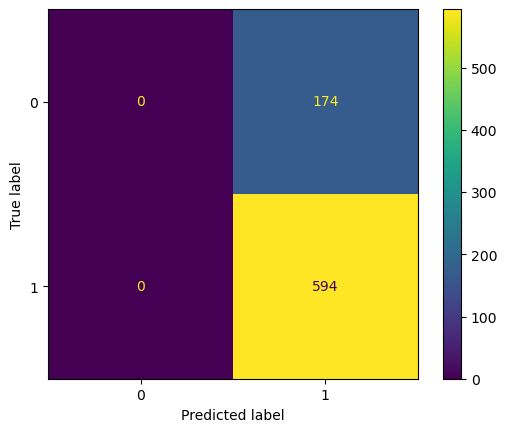

In [44]:
# Construct confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(df1['x_republican'], df1['x_republican_sgd'])
display = ConfusionMatrixDisplay(cm)
display.plot()

In [45]:
# Precision and Recall
from sklearn.metrics import precision_score, recall_score
print('Precision:',precision_score(df1['x_republican'], df1['x_republican_sgd']))
print('Recall:',recall_score(df1['x_republican'], df1['x_republican_sgd']))

Precision: 0.7734375
Recall: 1.0


In [46]:
#F1 score
from sklearn.metrics import f1_score
f1_score(df1['x_republican'],df1['x_republican_sgd'])

0.8722466960352423

### Precision/Recall Trade Off

(array([  6.,  58., 177., 252., 189.,  67.,  12.,   5.,   1.,   1.]),
 array([0.42178576, 0.62135103, 0.82091631, 1.02048158, 1.22004685,
        1.41961213, 1.6191774 , 1.81874268, 2.01830795, 2.21787323,
        2.4174385 ]),
 <BarContainer object of 10 artists>)

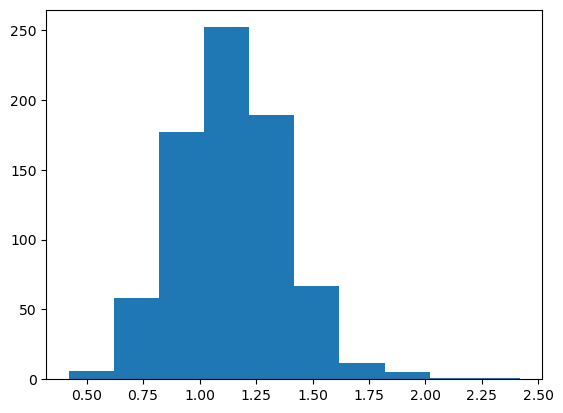

In [47]:
# scores used by SGDClassifier
import matplotlib.pyplot as plt

y_scores = sgd_clf.decision_function(df[features])
plt.hist(y_scores) # histogram of scores

In [48]:
# prediction using default threshold ... 
threshold = 0
(y_scores > threshold).mean()

np.float64(1.0)

In [49]:
# ... gives default model prediction
ypred = sgd_clf.predict(df[features])
ypred.mean()

np.float64(1.0)

In [50]:
# increasing threshold means more zeros are predicted
threshold = 1
(y_scores > threshold).mean()

np.float64(0.7265625)

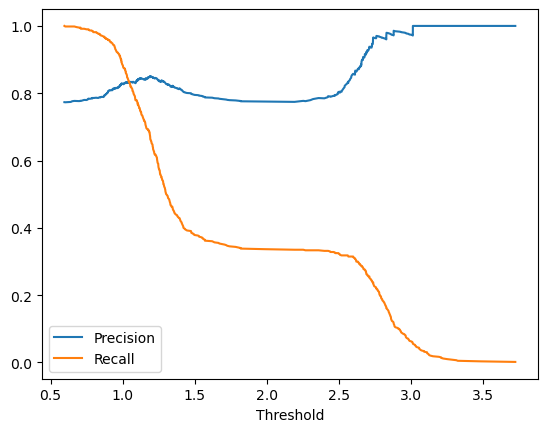

In [51]:
# Visualizing the precision/recall tradeoff
y_scores = cross_val_predict(sgd_clf,
                             df1[features],
                             df1['x_republican'],
                             cv=3,
                             method='decision_function',
                             n_jobs=3)

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(df1['x_republican'], y_scores)

import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel('Threshold')
plt.legend()

Text(0, 0.5, 'Precision')

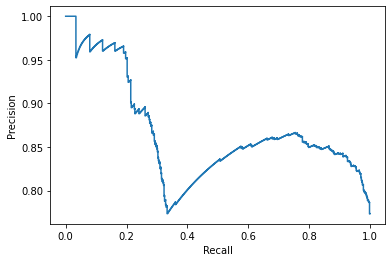

In [ ]:
# Plot precision vs recall
plt.step(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')

In [52]:
# Assessing other scoring thresholds
ypred_lower = y_scores > -1
ypred_higher = y_scores > 1

print('Precision for Low Threshold:',precision_score(y, ypred_lower))
print('Precision for High Threshold:',precision_score(y, ypred_higher))
print('Recall for Low Threshold:',recall_score(y, ypred_lower))
print('Recall for High Threshold:',recall_score(y, ypred_higher))

Precision for Low Threshold: 0.7734375
Precision for High Threshold: 0.8278041074249605
Recall for Low Threshold: 1.0
Recall for High Threshold: 0.8821548821548821


Text(0, 0.5, 'True Positive Rate')

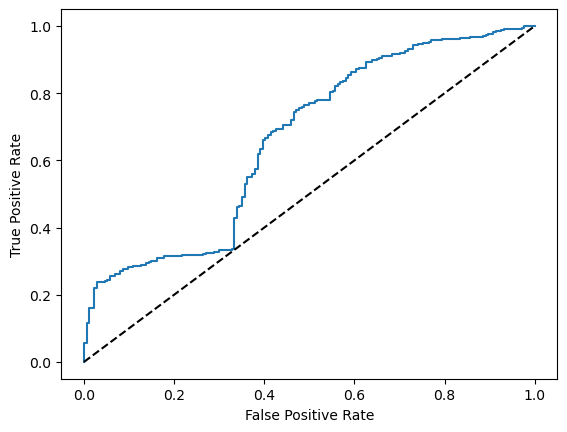

In [53]:
# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, y_scores)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [54]:
# AUC
from sklearn.metrics import roc_auc_score
roc_auc_score(y, y_scores)

0.6630771314679361

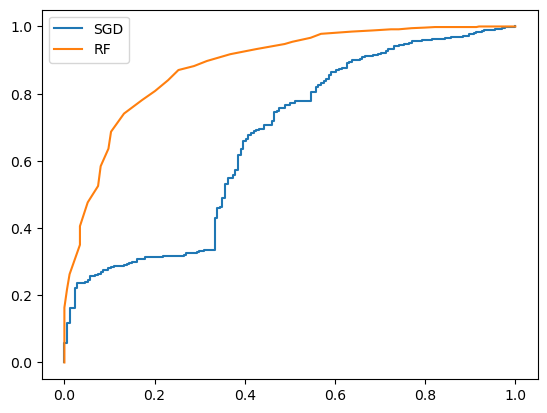

In [55]:
# Random Forests and predict_proba()
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
X500 = np.array(X500)
y_probas_rfc = cross_val_predict(rfc,
                                 X500,
                                 y,
                                 cv=3,
                                 method='predict_proba',
                                 n_jobs=3)

y_scores_rfc = y_probas_rfc[:,1]
fpr_rfc, tpr_rfc, thresholds_rfc = roc_curve(y,y_scores_rfc) 

# compare precision/recall tradeoff for SGD and RF classifiers
plt.plot(fpr, tpr, label="SGD")
plt.plot(fpr_rfc, tpr_rfc, label="RF")
plt.legend()

In [56]:
roc_auc_score(y,y_scores_rfc)

0.8842108827741012

## Multinomial Classification

In [57]:
author = df['authorship']
authpred = cross_val_predict(sgd_clf,
                              X500,
                              author,
                              cv=7)
print((authpred == author).mean())
list(zip(author[:8],authpred[:8]))

0.23177083333333334


[('ROBERTS', np.str_('GINSBURG')),
 ("O'CONNOR", np.str_('SCALIA')),
 ('GINSBURG', np.str_('GINSBURG')),
 ('STEVENS', np.str_('SOUTER')),
 ("O'CONNOR", np.str_('SCALIA')),
 ('THOMAS', np.str_('SCALIA')),
 ("O'CONNOR", np.str_('SCALIA')),
 ('STEVENS', np.str_('SCALIA'))]

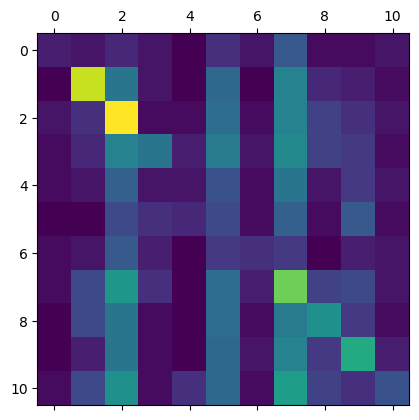

In [58]:
# Multi-class confusion matrix
conf_mx = confusion_matrix(author,authpred)
conf_mx
plt.matshow(conf_mx)
plt.show()

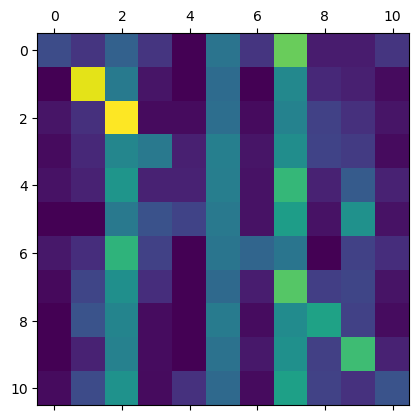

In [59]:
# normalize colors
conf_mx_norm = conf_mx / conf_mx.sum(axis=1, keepdims=True)
plt.matshow(conf_mx_norm)

## Multinomial Logistic

In [60]:

from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression(C=1, # default L2 penalty # .01, .1, 1, 2, 10
                              class_weight='balanced')

scores = cross_val_score(logistic,
                         Xscale[:1000],
                         author[:1000],
                         cv=3,
                         n_jobs=3)

scores.mean(), scores.std()

(np.float64(0.11458333333333333), np.float64(0.006639348324990605))

# Ensemble Learning

In [61]:
Y = df1['x_republican'] > 0

# Bagging classifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
        DecisionTreeClassifier(), n_estimators=50,
        max_samples=100, bootstrap=True, n_jobs=-1
    )

cross_val_score(bag_clf, X500, Y).mean()

np.float64(0.7877769289533996)

In [62]:
# random forest
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500, 
                                 max_leaf_nodes=16, 
                                 n_jobs=-1)
y_pred_rf = cross_val_predict(rnd_clf, X500, Y)                              
confusion_matrix(Y,y_pred_rf)

array([[  0, 174],
       [  0, 594]])

In [63]:
rnd_clf.fit(X500,Y)
feature_importances = rnd_clf.feature_importances_
sorted(zip(feature_importances, word), reverse=True)

[(np.float64(0.002791864883123891), 'r'),
 (np.float64(0.0019810452640752277), 'o'),
 (np.float64(0.0013589477774036986), 'k'),
 (np.float64(0.0008143475637659311), 'y')]

In [65]:
# XGBoost
from xgboost import XGBClassifier, XGBRegressor
dfX = pd.DataFrame(X500,columns=vocab)
xgb_clf = XGBClassifier()
cross_val_score(xgb_clf, dfX, Y).mean()

np.float64(0.8789067142008318)

In [66]:
xgb_reg = XGBRegressor(feature_names=vocab)
xgb_reg.fit(dfX,Y)
sorted(zip(xgb_reg.feature_importances_, vocab),reverse=True)[:10]

[(np.float32(0.042032972), 'related'),
 (np.float32(0.033604987), 'marks omitted'),
 (np.float32(0.03149722), 'cf'),
 (np.float32(0.031125838), 'added'),
 (np.float32(0.02902456), 'test'),
 (np.float32(0.02748574), 'statutory'),
 (np.float32(0.026704945), 'supra'),
 (np.float32(0.022595193), 'stated'),
 (np.float32(0.021525592), 'public'),
 (np.float32(0.02075818), 'say')]

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

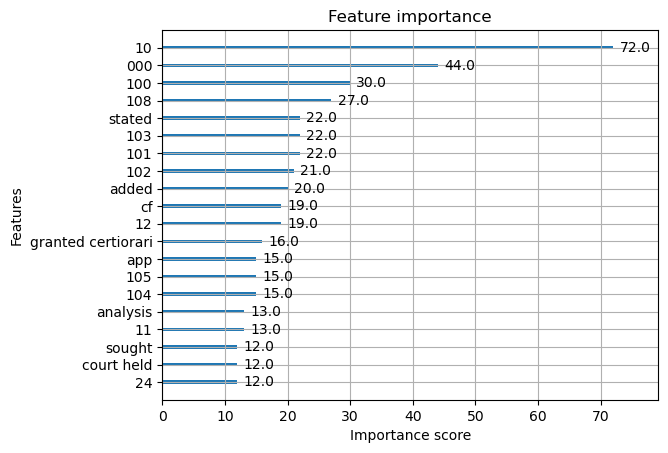

In [67]:
from xgboost import plot_importance
plot_importance(xgb_reg, max_num_features=20)

## PyTorch MLP 

[PyTorch](https://pytorch.org/) is the dominant DL framework nowadays.

**Classification**

In [68]:
# setup
%matplotlib notebook
# set this to your working directory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_pickle('sc_cases_cleaned.pkl',compression='gzip')
df=df.reset_index(drop=True)
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.9,  
                        max_features=1000,
                        stop_words='english',
                        ngram_range=(1,3))
X = vectorizer.fit_transform(df['opinion_text'])
pd.to_pickle(X,'X.pkl')
vocab = vectorizer.get_feature_names_out()
pd.to_pickle(vocab,'vocab.pkl')
Y = df['x_republican']

X.shape

(768, 1000)

In [69]:
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,sentiments,year,log_cite_count
0,"JOHN F. HINCK, ET UX. v. UNITED STATES",majority,2007-05-21,ROBERTS,1.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...",[],12.0,159.0,Chief Justice Roberts delivered the opinion of...,-0.999100,2007,5.068904
1,ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.,majority,2002-06-10,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,1234.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.997482,2002,7.118016
2,"REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...",majority,2002-01-22,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,2278.0,JUSTICE GINSBURG delivered the opinion of the ...,-0.997020,2002,7.731053
3,"CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...",majority,2003-04-22,STEVENS,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH']",2.0,1082.0,JUSTICE STEVENS delivered the opinion of the C...,-0.996996,2003,6.986566
4,NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...,majority,2000-04-17,O'CONNOR,1.0,"['BREYER, STEPHEN', 'KENNEDY, ANTHONY', ""O'CON...","['GINSBURG, RUTH', 'STEVENS, JOHN']",10.0,1449.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.996513,2000,7.278629


In [73]:
!pip install torchinfo


In [74]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from sklearn.model_selection import train_test_split
import math

if torch.backends.mps.is_available():
    device = 'mps'
elif torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

class ScCasesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


tsize = math.ceil(0.1 * len(Y))
X_train, X_valid, y_train, y_valid = train_test_split(
    X.toarray().astype('float32'), np.array(Y, dtype='float32'), test_size=tsize
)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=tsize)

train_dataset = ScCasesDataset(X_train, y_train)
valid_dataset = ScCasesDataset(X_valid, y_valid)
test_dataset = ScCasesDataset(X_test, y_test)

train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

input_dim = X.shape[1]

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, 50),
            nn.ReLU(),
            nn.Linear(50, 50),
            nn.ReLU(),
            nn.Linear(50, 1),
        )

    def forward(self, x):
        return self.layers(x)

model = MLP().to(device)
summary(model, input_size=(1, input_dim))


Layer (type:depth-idx)                   Output Shape              Param #
MLP                                      [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Linear: 2-1                       [1, 50]                   50,050
│    └─ReLU: 2-2                         [1, 50]                   --
│    └─Linear: 2-3                       [1, 50]                   2,550
│    └─ReLU: 2-4                         [1, 50]                   --
│    └─Linear: 2-5                       [1, 1]                    51
Total params: 52,651
Trainable params: 52,651
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.21
Estimated Total Size (MB): 0.22

In [76]:
!brew install graphviz
!pip install torchviz


==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
arf: Modern R console with syntax highlighting and fuzzy search
backplane-cli: CLI for interacting with the OpenShift Backplane API
cargo-insta: Snapshot testing CLI for Rust
fallow: Codebase intelligence for TypeScript and JavaScript
gascity: Orchestration-builder SDK for multi-agent coding workflows
lisette: Language inspired by Rust that compiles to Go
mado: Fast Markdown linter written in Rust
osdctl: CLI tool for managed OpenShift clusters
phpantom-lsp: Fast PHP language server written in Rust
skm: Simple and powerful SSH keys manager
tinyice: Modern, all-in-one Icecast-compatible audio/video streaming server
vcfanno: Annotate a VCF with other VCFs/BEDs/tabixed files
==> New Casks
agent

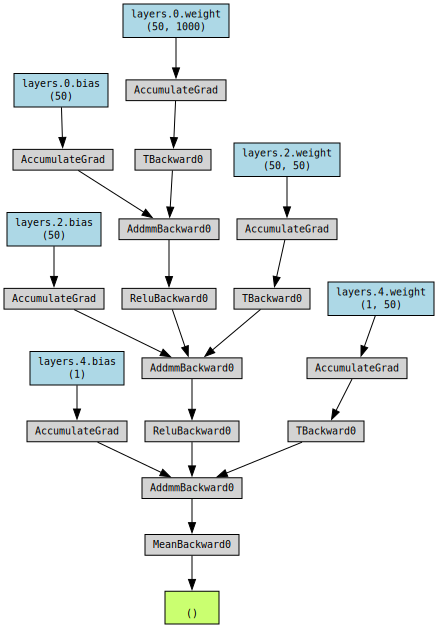

MLP(
  (layers): Sequential(
    (0): Linear(in_features=1000, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
)

In [80]:
# Visualize a model

# Requires graphviz!

# !brew install graphviz
# !pip install torchviz
import IPython.display
from torchviz import make_dot

dataiter = iter(valid_loader)
X_0, _ = next(dataiter)

model.cpu()
y_0 = model(X_0.float())
dot = make_dot(y_0.mean(), params=dict(model.named_parameters()))
IPython.display.display(dot)
model.to(device)

In [82]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
# fit the model
model = MLP().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.BCEWithLogitsLoss() # a binary cross entropy loss combined with a sigmoid activation

mean_train_losses = []
mean_valid_losses = []
valid_acc_list = []
epochs = 10
best_score = 0

for epoch in range(epochs):
    # switch the model to train mode
    model.train()
    
    train_losses = []
    valid_losses = []
    for i, (Xs, labels) in enumerate(train_loader):
        
        optimizer.zero_grad()
        
        outputs = model(Xs.float().to(device))
        loss = loss_fn(outputs, labels.float().unsqueeze(1).to(device)) # shape (32,) -> (32,1)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
            
    model.eval()
    pred_labels = []
    true_labels = []
    with torch.no_grad():
        for i, (Xs, labels) in enumerate(valid_loader):
            outputs = model(Xs.float().to(device))
            loss = loss_fn(outputs, labels.float().unsqueeze(1).to(device))
            
            valid_losses.append(loss.item())
            
            predicted = [1 if d > 0.5 else 0 for d in outputs.data.squeeze()]
            pred_labels.extend(predicted)
            true_labels.extend(list(labels))
            
    mean_train_losses.append(np.mean(train_losses))
    mean_valid_losses.append(np.mean(valid_losses))
    
    accuracy = accuracy_score(true_labels, pred_labels)
    if accuracy > best_score:
      torch.save(model, 'best.pt')
      best_score = accuracy
    valid_acc_list.append(accuracy)
    print('epoch : {}, train loss : {:.4f}, valid loss : {:.4f}, valid acc : {:.2f}%'\
         .format(epoch+1, np.mean(train_losses), np.mean(valid_losses), accuracy))

model = torch.load('best.pt', weights_only=False, map_location=device)
model.eval()

pred_labels = []
true_labels = []
for i, (Xs, labels) in enumerate(test_loader):
    outputs = model(Xs.float().to(device))
    
    pred = [1 if d > 0.5 else 0 for d in outputs.data.squeeze()]
    pred_labels.extend(pred)
    true_labels.extend(list(labels))

print('test accuracy:', accuracy_score(true_labels, pred_labels))

epoch : 1, train loss : 0.5883, valid loss : 0.4556, valid acc : 0.79%
epoch : 2, train loss : 0.4231, valid loss : 0.3807, valid acc : 0.84%
epoch : 3, train loss : 0.2872, valid loss : 0.2988, valid acc : 0.78%
epoch : 4, train loss : 0.1406, valid loss : 0.2426, valid acc : 0.84%
epoch : 5, train loss : 0.0480, valid loss : 0.2664, valid acc : 0.84%
epoch : 6, train loss : 0.0171, valid loss : 0.2913, valid acc : 0.86%
epoch : 7, train loss : 0.0073, valid loss : 0.3135, valid acc : 0.86%
epoch : 8, train loss : 0.0044, valid loss : 0.3346, valid acc : 0.84%
epoch : 9, train loss : 0.0029, valid loss : 0.3501, valid acc : 0.86%
epoch : 10, train loss : 0.0020, valid loss : 0.3645, valid acc : 0.86%
test accuracy: 0.8571428571428571


In [83]:
# these are the learned coefficients
for name, param in model.named_parameters():
  print(name)
  print(param.shape)
  print(param)

layers.0.weight
torch.Size([50, 1000])
Parameter containing:
tensor([[ 0.0104,  0.0043, -0.0034,  ...,  0.0082, -0.0048,  0.0010],
        [-0.0276, -0.0218, -0.0040,  ..., -0.0180, -0.0171, -0.0112],
        [-0.0213,  0.0094, -0.0202,  ..., -0.0090, -0.0286,  0.0354],
        ...,
        [-0.0037, -0.0233,  0.0126,  ..., -0.0308, -0.0162,  0.0004],
        [-0.0260, -0.0233,  0.0020,  ..., -0.0203, -0.0270,  0.0208],
        [-0.0360,  0.0175, -0.0154,  ..., -0.0016, -0.0020, -0.0139]],
       device='mps:0', requires_grad=True)
layers.0.bias
torch.Size([50])
Parameter containing:
tensor([-2.4255e-02, -1.8526e-02, -1.2959e-02,  1.5288e-02, -1.8269e-02,
        -2.1741e-02, -2.0297e-04, -1.8153e-02, -3.2313e-05, -3.5888e-02,
         2.0028e-03, -4.1601e-02,  4.4406e-03,  1.0749e-03, -4.8685e-03,
         3.9103e-02, -7.7180e-03,  3.5082e-03, -1.1313e-02,  4.3876e-02,
        -1.1423e-02, -1.5869e-02,  4.6137e-03, -1.2617e-02, -1.2426e-02,
        -6.8462e-03, -5.4982e-03,  4.3642e-0

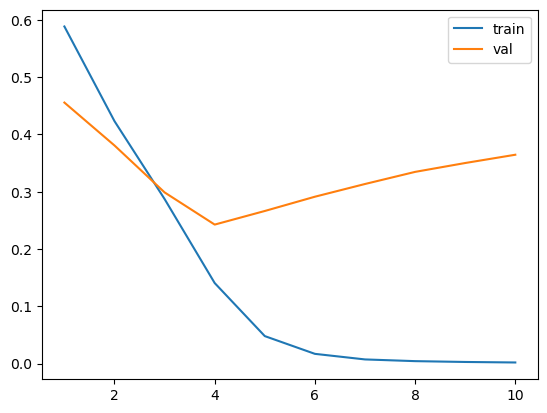

In [84]:
# Plot performance by epoch
%matplotlib inline
plt.plot(list(range(1, 11)), mean_train_losses)
plt.plot(list(range(1, 11)), mean_valid_losses)
plt.legend(['train', 'val'], loc='best')


**Regression**

In [85]:
from sklearn.metrics import r2_score

# Regression model with R-squared
Yreg = df['log_cite_count']

# prepare regression dataset
tsize = math.ceil(0.1 * len(Y))
X_train, X_valid, y_train, y_valid = train_test_split(X.toarray(), np.array(Yreg), test_size=tsize)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=tsize)

train_dataset = ScCasesDataset(X_train, y_train)
valid_dataset = ScCasesDataset(X_valid, y_valid)
test_dataset = ScCasesDataset(X_test, y_test)
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

model = MLP().to(device) # create a model for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss() # we use Mean Square Error for regression

mean_train_losses = []
mean_valid_losses = []
valid_r2_list = []
epochs = 15
best_score = 0

for epoch in range(epochs):
    # switch the model to train mode
    model.train()
    
    train_losses = []
    valid_losses = []
    for i, (Xs, labels) in enumerate(train_loader):
        
        optimizer.zero_grad()
        
        outputs = model(Xs.float().to(device))
        loss = loss_fn(outputs, labels.float().unsqueeze(1).to(device)) # shape (32,) -> (32,1)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
            
    model.eval()
    pred_labels = []
    true_labels = []
    with torch.no_grad():
        for i, (Xs, labels) in enumerate(valid_loader):
            outputs = model(Xs.float().to(device))
            loss = loss_fn(outputs, labels.float().unsqueeze(1).to(device))
            
            valid_losses.append(loss.item())
            
            predicted = outputs.data.squeeze()
            pred_labels.extend(list(predicted.cpu()))
            true_labels.extend(list(labels.cpu()))
            
    mean_train_losses.append(np.mean(train_losses))
    mean_valid_losses.append(np.mean(valid_losses))
    
    r2 = r2_score(true_labels, pred_labels)
    if r2 > best_score:
      torch.save(model, 'best.pt')
      best_score = r2
    valid_r2_list.append(r2)
    print('epoch : {}, train loss : {:.4f}, valid loss : {:.4f}, valid r2 : {:.2f}%'\
         .format(epoch+1, np.mean(train_losses), np.mean(valid_losses), r2))
    
model = torch.load('best.pt', weights_only=False, map_location=device)
model.eval()

pred_labels = []
true_labels = []
for i, (Xs, labels) in enumerate(test_loader):
    outputs = model(Xs.float().to(device))
    
    pred = outputs.data.squeeze()
    pred_labels.extend(list(pred.cpu()))
    true_labels.extend(list(labels.cpu()))

print('test r2:', r2_score(true_labels, pred_labels))

epoch : 1, train loss : 17.5488, valid loss : 15.8005, valid r2 : -5.46%
epoch : 2, train loss : 8.1634, valid loss : 10.6038, valid r2 : -2.77%
epoch : 3, train loss : 5.7842, valid loss : 8.3065, valid r2 : -2.01%
epoch : 4, train loss : 4.5388, valid loss : 6.8171, valid r2 : -1.63%
epoch : 5, train loss : 3.6095, valid loss : 5.9171, valid r2 : -1.42%
epoch : 6, train loss : 3.0497, valid loss : 5.6046, valid r2 : -1.31%
epoch : 7, train loss : 2.5850, valid loss : 5.6504, valid r2 : -1.36%
epoch : 8, train loss : 2.1535, valid loss : 5.6045, valid r2 : -1.38%
epoch : 9, train loss : 1.7836, valid loss : 6.1721, valid r2 : -1.66%
epoch : 10, train loss : 1.3559, valid loss : 6.3622, valid r2 : -1.68%
epoch : 11, train loss : 1.1318, valid loss : 6.1795, valid r2 : -1.69%
epoch : 12, train loss : 0.7492, valid loss : 6.7142, valid r2 : -1.83%
epoch : 13, train loss : 0.5771, valid loss : 6.6401, valid r2 : -2.00%
epoch : 14, train loss : 0.4250, valid loss : 7.7000, valid r2 : -2.31

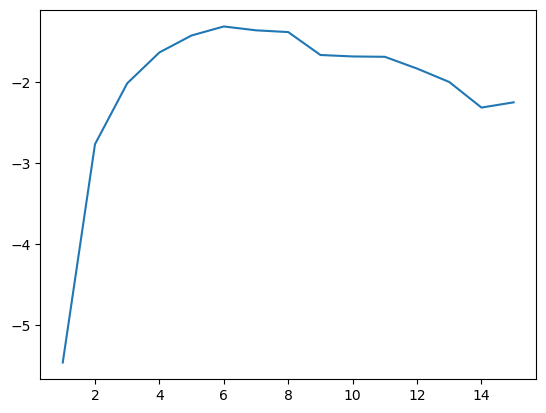

In [86]:
%matplotlib inline

# Plot performance by epoch
plt.plot(list(range(1, 16)), valid_r2_list)
